In [4]:
import pandas as pd

df = pd.read_excel(r"C:\Users\Usama\Downloads\intern_feedback_dataset.xlsx")
print(df.head())

   intern_id                                           feedback
0          1  The internship program was very helpful and in...
1          2  Mentors were supportive and explained tasks cl...
2          3            I learned many new data analysis skills
3          4                The workload was sometimes too much
4          5                Communication with mentors was good


In [6]:
pip install nltk

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.5 MB 1.1 MB/s eta 0:00:01
   ---------------------------------- ----- 1.3/1.5 MB 2.0 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 1.6 MB/s  0:00:01

   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------- ---


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

In [8]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Usama\AppData\Roaming\nltk_data...


True

In [9]:
sia = SentimentIntensityAnalyzer()

In [11]:
df["score"] = df["feedback"].apply(lambda x: sia.polarity_scores(x)["compound"])

In [12]:
def sentiment_label(score):
    
    if score > 0:
        return "Positive"
    
    elif score == 0:
        return "Neutral"
    
    else:
        return "Negative"

df["sentiment"] = df["score"].apply(sentiment_label)

df.head()

,intern_id,feedback,score,sentiment
0,1,The internship program was very helpful and in...,0.4754,Positive
1,2,Mentors were supportive and explained tasks cl...,0.5994,Positive
2,3,I learned many new data analysis skills,0.0000,Neutral
3,4,The workload was sometimes too much,0.0000,Neutral
4,5,Communication with mentors was good,0.4404,Positive


In [13]:
df["sentiment"].value_counts()

sentiment
Positive    18
Neutral      9
Negative     3
Name: count, dtype: int64

In [14]:
df["sentiment"].value_counts(normalize=True) * 100

sentiment
Positive    60.0
Neutral     30.0
Negative    10.0
Name: proportion, dtype: float64

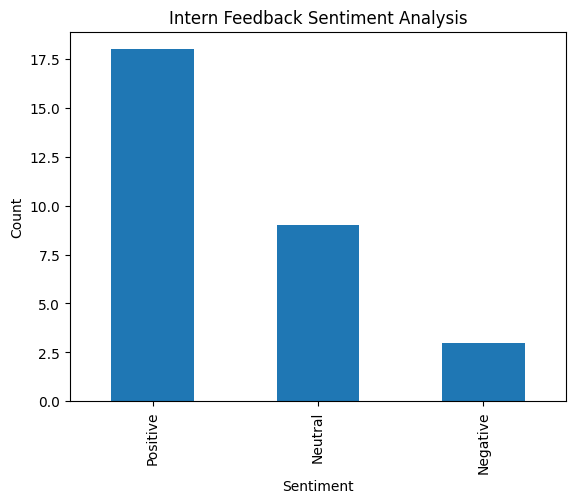

In [15]:
import matplotlib.pyplot as plt

df["sentiment"].value_counts().plot(kind="bar")

plt.title("Intern Feedback Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()